# Bio-Argo match-ups
**Author:** Eli Holmes (NOAA)</br>
Last updated: November 21, 2025

We have upwards of 33k bbp700 and 10k chl-a points for the global bio-Argo data. The goal is to get the Rrs data, all bands, for each of these. However, with so many points we need to be careful with memory. Just opening the meta-data for all the Rrs files, 500+ days since March 2024, will eat up a lot of memory.

**What do we do?**

1. When we open the PACE Rrs files, we create `ds` with `chunks{}` so that dask knows the chunk structure.
2. We compute the vector of indices for the Argo points and use `ds.vindex([vector_i, vector_j)`. That will load only the needed chunks.
3. We work through the files in batches and use a dask cluster that we close after finishing with a batch. This will keep the memory from exploding on us as we open files.

**Dask cluster workflow**

1. Create a function to process one file
2. Create a batch for loop that does
    * Grab a batch of file urls (to their location in the cloud)
    * Open a dask cluster
    * Process the files with the process file function
    * Close the cluster when done
    * Grab the next batch of file urls
    * Repeat


## Load the Argo data

In [7]:
# Load data from GitHub
df_y_name="CHLA"; df_lat_name="LATITUDE"; df_lon_name="LONGITUDE"; df_time_name="TIME"
import pandas as pd
base_url="https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/tutorial_data/"
url = f"{base_url}argo_bgc_global_profile_{df_y_name}.parquet"
argo_chl_df = pd.read_parquet(url)

## Load custom functions

In [27]:
# --- Custom python functions ---
import os, importlib
# Looks to see if you have the file already and if not, downloads from GitHub
if not os.path.exists("ml_utils.py"):
    !wget -q https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/ml_utils.py

import ml_utils as mu
importlib.reload(mu)

<module 'ml_utils' from '/home/jovyan/2025-tutorials/ml_utils.py'>

## Get the file urls for the PACE Data

In [2]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)
import xarray as xr
df = argo_chl_df
rrs_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_RRS",
    temporal = (df.TIME.min(), df.TIME.max()),
    granule_name="*.DAY.*.4km.nc"
)
# all days since Mar 2024; pqdm args to quiet output
fileset = earthaccess.open(rrs_results, pqdm_kwargs={"disable": True} );

Check the format of individuals day data.

In [20]:
import xarray as xr
ds = xr.open_dataset(
        fileset[0],
        chunks={}
    )
ds

<xarray.Dataset> Size: 26GB
Dimensions:     (wavelength: 172, lat: 4320, lon: 8640, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 1kB 346.0 348.0 351.0 ... 714.0 717.0 719.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    Rrs         (lat, lon, wavelength) float32 26GB dask.array<chunksize=(16, 1024, 8), meta=np.ndarray>
    palette     (rgb, eightbitcolor) uint8 768B dask.array<chunksize=(3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20240305.L3m.DAY.RRS.V3_1.Rrs...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/RRS/3.1
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         3861548
    data_minimum:                      -0.009998
    data_maximum:                      0.092371605

# Workflow to process one file

Assume:

* The files are for a regular grid, i.e. level 3 data
* The files do not have a time coordinate. This is how the PACE level 3 daily and 8-day files are currently structured.
* We are looking at a variable, like Rrs, that has a 3rd dimension of wavelength or similar. Usually called wavelength or wavelength_3d. So the dims are (lat, lon, 3rd dim)
* `time_coverage_start` and `time_coverage_end` exist as attributes in the files.
* `ds[ds_vec_name]` is a 1D coordinate aligned with the last dimension of ds_var_name.

Process Steps:

1.  Subset our Argo dataframe to only those rows within in the  time window covered by the cloud-hosted xarray dataset (`ds`). Let's call that `df_day`
2.  Get the lat/lon indices of `ds` that correspond to the lat/lon rows in `df_day`. These indices will look like `[0, 3, 6]` and `[0, 10, 15]` corresponding to index pairs, like `(3, 10)` corresponding to the lat/lon pair in a row of `df_day`.
3.  Do a fast point retrieval from `ds`. `ds` is cloud optimized (chunked) file and we only want to the chunks that we need. We do not need to load all the chunks. I/O of cloud-hosted data is the slow part so don't touch more of the data than you need to.
4. Build a dataframe with the predictor variables that we want from `ds`.

## Run through the PACE files in batches

Just in case something hangs.

### Create a function to run a batch

* create cluster
* run `process_one_file` using `.map` over all file urls
* gather results (pandas dataframe)
* close cluster and return results

In [23]:
# run_batch function
import pandas as pd
def run_batch(batch_results):
    results = []
    for k, res in enumerate(batch_results, start=1):
        res = process_one_file(res)
        results.append(res)
    return pd.concat(results, ignore_index=True)

In [24]:
%%time
# test that it runs
run_batch(results[0:1])

CPU times: user 3.31 s, sys: 1.11 s, total: 4.42 s
Wall time: 17.5 s


,time,lat,lon,y,df_lat,df_lon,Rrs_346,Rrs_348,Rrs_351,Rrs_353,...,Rrs_706,Rrs_707,Rrs_708,Rrs_709,Rrs_711,Rrs_712,Rrs_713,Rrs_714,Rrs_717,Rrs_719
0,2024-03-05 11:39:00+00:00,-45.770836,136.562515,0.727765,-45.756765,136.574703,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-03-05 06:58:45.000999936+00:00,-34.145836,-165.729172,0.023080,-34.152200,-165.736500,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-03-06 00:25:00+00:00,-31.895838,37.145840,0.018225,-31.877871,37.132439,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-03-06 01:11:24+00:00,-10.687503,49.729172,0.202350,-10.701914,49.728228,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-03-05 08:16:05.000999936+00:00,0.687497,-165.437500,0.514266,0.673300,-165.453300,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-03-05 15:35:00+00:00,39.145832,-66.562500,0.317225,39.151501,-66.574600,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-03-05 01:16:05+00:00,29.062498,-17.229162,0.881961,29.082600,-17.213600,0.006416,0.0069,0.007244,0.007086,...,0.000218,0.000218,0.000224,0.000214,0.000214,0.000196,0.000174,0.000166,0.00016,0.000214
7,2024-03-05 02:08:10+00:00,25.104164,148.145844,0.036300,25.111515,148.146488,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-03-05 11:37:00+00:00,68.062500,-5.104161,0.036000,68.045173,-5.118235,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-03-05 11:32:39.019000064+00:00,69.687500,4.187506,0.021900,69.673916,4.204859,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## For loop over our batches

* get urls for a batch of 20 PACE files in cloud
* save results to a file in case the process crashes
* later we will reconstruct from the files. The files are small.

## CHLA

In [12]:
%%time
from datetime import datetime

def run_batch(
    results, df, 
    ds_vec_name="wavelength", ds_var_name="Rrs", ds_vec_sel=None,
    df_time_name="TIME", df_lat_name="LATITUDE", df_lon_name="LONGITUDE"
):
    # Make sure to refresh fileset to minimize the chance that the token expires before we are done
    # this for loop consumes about 6Gb of RAM
    fileset = earthaccess.open(results, pqdm_kwargs={"disable": True} );
    
    df_plus = []
    for i, f in enumerate(fileset):
        df_record, pts = mu.one_file_matches(
            f, df, 
            ds_vec_name=ds_vec_name, ds_var_name=ds_var_name, ds_vec_sel=ds_vec_sel,
            df_time_name=df_time_name, df_lat_name=df_lat_name, df_lon_name=df_lon_name)
        if df_record is None or len(df_record) == 0: 
            print(f"Skipped day {i} no data in df")
            continue
        # error check
        if len(df_record) != len(pts):
            raise ValueError(f"Row mismatch: df_record={len(df_record)}, pts={len(pts)}")
    
        # left "concat": keep df_record rows, add pts columns by position
        df_record_plus = pd.concat(
            [ 
                df_record.reset_index(drop=True), 
                pts.reset_index(drop=True),
            ], axis=1,)
        df_plus.append(df_record_plus)
    df_plus = pd.concat(df_plus, ignore_index=True)
    return df_plus

CPU times: user 11 μs, sys: 0 ns, total: 11 μs
Wall time: 13.8 μs


In [7]:
%%time
# test that it works
res=run_batch(rrs_results[0:1], df)
res.head()

CPU times: user 2.8 s, sys: 535 ms, total: 3.34 s
Wall time: 6.34 s


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_INT_150,CHLA_0_10,CHLA_10_20,CHLA_20_30,CHLA_30_40,...,pace_Rrs_706,pace_Rrs_707,pace_Rrs_708,pace_Rrs_709,pace_Rrs_711,pace_Rrs_712,pace_Rrs_713,pace_Rrs_714,pace_Rrs_717,pace_Rrs_719
0,5905501,138,2024-03-05 11:39:00.000000000,-45.756765,136.574703,0.453890,0.728420,0.724488,0.746167,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5906304,116,2024-03-05 06:58:45.000999936,-34.152200,-165.736500,0.136303,0.021424,0.024736,0.027732,0.035617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4902628,48,2024-03-06 00:25:00.000000000,-31.877871,37.132439,0.125606,0.018233,NaN,0.029833,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6990505,54,2024-03-06 01:11:24.000000000,-10.701914,49.728228,0.119282,0.202350,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2903856,19,2024-03-05 08:16:05.000999936,0.673300,-165.453300,0.338660,0.489632,0.533973,0.570546,0.718737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "chla_profile"
results = rrs_results
df = argo_chl_df
ds_var = "Rrs"

for batch_idx, i in enumerate(range(0, len(fileset), batch_size), start=1):
    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files: {datetime.now():%H:%M:%S}")

    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_{ds_var}_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    df_batch = run_batch(batch, df)  # returns a DataFrame

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")


Batch 1: 10 files: 08:48:08
Skipped day 8 no data in df
  -> Saved 158 rows to data/matchups/chla_profile_matchups_Rrs_batch_001.parquet
Batch 2: 10 files: 08:49:00
Skipped day 8 no data in df
  -> Saved 173 rows to data/matchups/chla_profile_matchups_Rrs_batch_002.parquet
Batch 3: 10 files: 08:49:57
Skipped day 0 no data in df
Skipped day 1 no data in df
  -> Saved 164 rows to data/matchups/chla_profile_matchups_Rrs_batch_003.parquet
Batch 4: 10 files: 08:50:57
  -> Saved 205 rows to data/matchups/chla_profile_matchups_Rrs_batch_004.parquet
Batch 5: 10 files: 08:52:04
  -> Saved 195 rows to data/matchups/chla_profile_matchups_Rrs_batch_005.parquet
Batch 6: 10 files: 08:53:07
  -> Saved 187 rows to data/matchups/chla_profile_matchups_Rrs_batch_006.parquet
Batch 7: 10 files: 08:54:07
  -> Saved 195 rows to data/matchups/chla_profile_matchups_Rrs_batch_007.parquet
Batch 8: 10 files: 08:55:11
  -> Saved 191 rows to data/matchups/chla_profile_matchups_Rrs_batch_008.parquet
Batch 9: 10 file

In [31]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
var = "chla_profile"
ds_var = "Rrs"

batch_files = sorted(results_dir.glob(f"{var}_matchups_{ds_var}_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"tutorial_data/{var}_argo_{ds_var}_all.parquet", index=False)


In [32]:
print(f"Total rows: {len(df_all)}")

Total rows: 14172


### Same idea. Add on the PACE CHLA data


In [25]:
# --- Custom python functions ---
import os, importlib
# Looks to see if you have the file already and if not, downloads from GitHub
if not os.path.exists("ml_utils.py"):
    !wget -q https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/ml_utils.py

import ml_utils as mu
importlib.reload(mu)

<module 'ml_utils' from '/home/jovyan/2025-tutorials/ml_utils.py'>

In [8]:
# Add on chla to the clean parquet
import pandas as pd
import earthaccess
import xarray as xr

# Get PACE CHL data
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)
import xarray as xr
chl_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_CHL",
    temporal = (argo_chl_df.TIME.min(), argo_chl_df.TIME.max()),
    granule_name="*.DAY.*.4km.nc"
)
print(f"{len(chl_results)} days of PACE data")

560 days of PACE data


In [16]:
%%time
# test that it works
res = run_batch(chl_results[0:1], argo_chl_df, ds_vec_name=None, ds_var_name="chlor_a")
res.head()

CPU times: user 205 ms, sys: 37 ms, total: 242 ms
Wall time: 413 ms


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_INT_150,CHLA_0_10,CHLA_10_20,CHLA_20_30,CHLA_30_40,...,CHLA_160_170,CHLA_170_180,CHLA_180_190,CHLA_190_200,pace_chlor_a_file,pace_chlor_a_t_start,pace_chlor_a_t_end,pace_chlor_a_lat,pace_chlor_a_lon,pace_chlor_a
0,5905501,138,2024-03-05 11:39:00.000000000,-45.756765,136.574703,0.453890,0.728420,0.724488,0.746167,NaN,...,NaN,0.012100,0.014789,0.009680,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-45.770836,136.562515,NaN
1,5906304,116,2024-03-05 06:58:45.000999936,-34.152200,-165.736500,0.136303,0.021424,0.024736,0.027732,0.035617,...,0.071100,0.049810,0.026313,0.011805,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-34.145836,-165.729172,NaN
2,4902628,48,2024-03-06 00:25:00.000000000,-31.877871,37.132439,0.125606,0.018233,NaN,0.029833,NaN,...,0.010295,-0.001542,NaN,-0.003700,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-31.895838,37.145840,NaN
3,6990505,54,2024-03-06 01:11:24.000000000,-10.701914,49.728228,0.119282,0.202350,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-10.687503,49.729172,NaN
4,2903856,19,2024-03-05 08:16:05.000999936,0.673300,-165.453300,0.338660,0.489632,0.533973,0.570546,0.718737,...,0.007165,0.002302,0.001880,0.002091,PACE_OCI.20240305.L3m.DAY.CHL.V3_1.chlor_a.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,0.687497,-165.437500,NaN


In [18]:
from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "chla_profile"
results = chl_results
df = argo_chl_df
ds_var = "chlor_a"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files: {datetime.now():%H:%M:%S}")

    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_{ds_var}_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    df_batch = run_batch(batch, df, ds_vec_name=None, ds_var_name="chlor_a")

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")

Batch 1: 10 files: 11:30:29
Skipped day 8 no data in df
  -> Saved 158 rows to data/matchups/chla_profile_matchups_chlor_a_batch_001.parquet
Batch 2: 10 files: 11:30:36
Skipped day 8 no data in df
  -> Saved 173 rows to data/matchups/chla_profile_matchups_chlor_a_batch_002.parquet
Batch 3: 10 files: 11:30:44
Skipped day 0 no data in df
Skipped day 1 no data in df
  -> Saved 164 rows to data/matchups/chla_profile_matchups_chlor_a_batch_003.parquet
Batch 4: 10 files: 11:30:49
  -> Saved 205 rows to data/matchups/chla_profile_matchups_chlor_a_batch_004.parquet
Batch 5: 10 files: 11:30:55
  -> Saved 195 rows to data/matchups/chla_profile_matchups_chlor_a_batch_005.parquet
Batch 6: 10 files: 11:31:00
  -> Saved 187 rows to data/matchups/chla_profile_matchups_chlor_a_batch_006.parquet
Batch 7: 10 files: 11:31:05
  -> Saved 195 rows to data/matchups/chla_profile_matchups_chlor_a_batch_007.parquet
Batch 8: 10 files: 11:31:10
  -> Saved 191 rows to data/matchups/chla_profile_matchups_chlor_a_ba

In [19]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
var = "chla_profile"
ds_var = "chlor_a"

batch_files = sorted(results_dir.glob(f"{var}_matchups_{ds_var}_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"tutorial_data/{var}_argo_{ds_var}_all.parquet", index=False)


### Same idea. Add on the PACE Kd490 data


In [20]:
# Add on chla to the clean parquet
import pandas as pd
import earthaccess
import xarray as xr

# Get PACE CHL data
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)
import xarray as xr
kd_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_KD",
    temporal = (argo_chl_df.TIME.min(), argo_chl_df.TIME.max()),
    granule_name="*.DAY.*.4km.nc"
)
print(f"{len(kd_results)} days of PACE data")

560 days of PACE data


In [28]:
%%time
# test that it works
res = run_batch(kd_results[0:1], argo_chl_df, ds_var_name="Kd", ds_vec_sel=490.0)
res.head()

CPU times: user 364 ms, sys: 32.3 ms, total: 396 ms
Wall time: 935 ms


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_INT_150,CHLA_0_10,CHLA_10_20,CHLA_20_30,CHLA_30_40,...,CHLA_160_170,CHLA_170_180,CHLA_180_190,CHLA_190_200,pace_Kd_file,pace_Kd_t_start,pace_Kd_t_end,pace_Kd_lat,pace_Kd_lon,pace_Kd_490
0,5905501,138,2024-03-05 11:39:00.000000000,-45.756765,136.574703,0.453890,0.728420,0.724488,0.746167,NaN,...,NaN,0.012100,0.014789,0.009680,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-45.770836,136.562515,NaN
1,5906304,116,2024-03-05 06:58:45.000999936,-34.152200,-165.736500,0.136303,0.021424,0.024736,0.027732,0.035617,...,0.071100,0.049810,0.026313,0.011805,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-34.145836,-165.729172,NaN
2,4902628,48,2024-03-06 00:25:00.000000000,-31.877871,37.132439,0.125606,0.018233,NaN,0.029833,NaN,...,0.010295,-0.001542,NaN,-0.003700,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-31.895838,37.145840,NaN
3,6990505,54,2024-03-06 01:11:24.000000000,-10.701914,49.728228,0.119282,0.202350,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,-10.687503,49.729172,NaN
4,2903856,19,2024-03-05 08:16:05.000999936,0.673300,-165.453300,0.338660,0.489632,0.533973,0.570546,0.718737,...,0.007165,0.002302,0.001880,0.002091,PACE_OCI.20240305.L3m.DAY.KD.V3_1.Kd.4km.nc,2024-03-05 00:08:58.225000+00:00,2024-03-06 02:07:24.895000+00:00,0.687497,-165.437500,NaN


In [35]:
from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "chla_profile"
results = kd_results
df = argo_chl_df
ds_var = "Kd"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files: {datetime.now():%H:%M:%S}")

    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_{ds_var}_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    df_batch = run_batch(batch, argo_chl_df, ds_var_name="Kd", ds_vec_sel=490.0)

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")

Batch 1: 10 files: 11:54:44
  -> Skipping batch 1, found data/matchups/chla_profile_matchups_Kd_batch_001.parquet
Batch 2: 10 files: 11:54:44
  -> Skipping batch 2, found data/matchups/chla_profile_matchups_Kd_batch_002.parquet
Batch 3: 10 files: 11:54:44
Skipped day 0 no data in df
Skipped day 1 no data in df
  -> Saved 164 rows to data/matchups/chla_profile_matchups_Kd_batch_003.parquet
Batch 4: 10 files: 11:54:53
  -> Saved 205 rows to data/matchups/chla_profile_matchups_Kd_batch_004.parquet
Batch 5: 10 files: 11:55:04
  -> Saved 195 rows to data/matchups/chla_profile_matchups_Kd_batch_005.parquet
Batch 6: 10 files: 11:55:15
  -> Saved 187 rows to data/matchups/chla_profile_matchups_Kd_batch_006.parquet
Batch 7: 10 files: 11:55:25
  -> Saved 195 rows to data/matchups/chla_profile_matchups_Kd_batch_007.parquet
Batch 8: 10 files: 11:55:35
  -> Saved 191 rows to data/matchups/chla_profile_matchups_Kd_batch_008.parquet
Batch 9: 10 files: 11:55:46
  -> Saved 184 rows to data/matchups/chl

In [36]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
var = "chla_profile"
ds_var = "Kd"

batch_files = sorted(results_dir.glob(f"{var}_matchups_{ds_var}_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"tutorial_data/{var}_argo_{ds_var}_all.parquet", index=False)


### Merge all PACE variables

In [46]:
# When everything is done, you can merge all batches:
import pandas as pd
import numpy as np

df_all_kd = pd.read_parquet(f"tutorial_data/{var}_argo_Kd_all.parquet")
df_all_chl = pd.read_parquet(f"tutorial_data/{var}_argo_chlor_a_all.parquet")
df_all_rrs = pd.read_parquet(f"tutorial_data/{var}_argo_Rrs_all.parquet")

# check 
assert np.array_equal(
    df_all_chl.iloc[:, :5].values,
    df_all_rrs.iloc[:, :5].values
), "First 9 column values differ"

assert np.array_equal(
    df_all_kd.iloc[:, :5].values,
    df_all_rrs.iloc[:, :5].values
), "First 9 column values differ"

# Identify columns to *not* duplicate
common_cols = df_all_rss.columns.intersection(df_all_chl.columns)
# Keep only the "new" columns from df_all_chl
df_chl_extra = df_all_chl.drop(columns=common_cols)
df_kd_extra = df_all_kd.drop(columns=common_cols)
# Horizontal concat: rss on the left, extras on the right
df_merged = pd.concat([df_all_rss, df_chl_extra, df_kd_extra], axis=1)
df_merged.to_parquet(f"tutorial_data/{var}_argo_Rss_chlor_a_Kd_all.parquet", index=False)

# Cleaned; no missing Rrs
rrs_cols = [c for c in df_merged.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
df_merged_clean = df_merged.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
df_merged_clean.to_parquet(f"tutorial_data/{var}_argo_Rss_chlor_a_Kd.parquet", index=False)


In [69]:
import pandas as pd
print(df_merged_clean.shape)
m = np.isfinite(df_merged_clean["CHLA_0_10"]) | np.isfinite(df_merged_clean["CHLA_10_20"])
print(df_merged_clean[m].shape)
print(df_merged_clean.dropna(subset="CHLA_0_10", how="all").shape)
df_merged_clean.columns

(2678, 215)
(1561, 215)
(1335, 215)


Index(['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'TIME', 'LATITUDE', 'LONGITUDE',
       'CHLA_INT_150', 'CHLA_0_10', 'CHLA_10_20', 'CHLA_20_30', 'CHLA_30_40',
       ...
       'pace_chlor_a_t_end', 'pace_chlor_a_lat', 'pace_chlor_a_lon',
       'pace_chlor_a', 'pace_Kd_file', 'pace_Kd_t_start', 'pace_Kd_t_end',
       'pace_Kd_lat', 'pace_Kd_lon', 'pace_Kd_490'],
      dtype='object', length=215)

## Illustrate the effect of solar hour

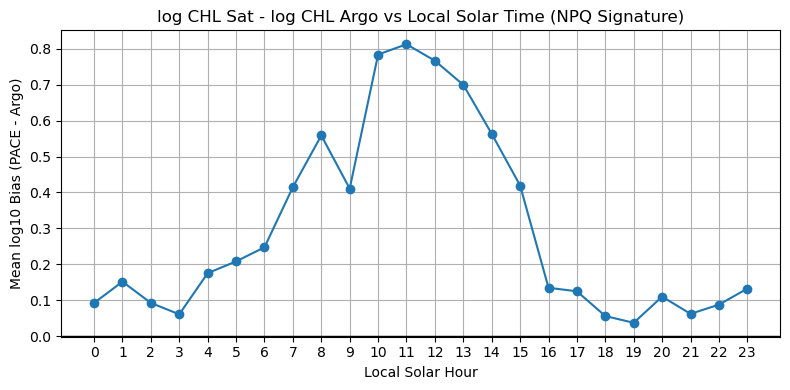

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================
#  CHL bias vs local solar time
# ============================

df = pd.read_parquet(f"tutorial_data/{var}_argo_Rss_chlor_a_Kd.parquet")

df_bias = df.copy()

# --- Ensure datetime ---
df_bias['TIME'] = pd.to_datetime(df_bias['TIME'], utc=True, errors='coerce')

# --- Basic cleaning: drop rows missing key fields ---
df_bias = df_bias.dropna(subset=['TIME', 'LONGITUDE', 'CHLA_0_10', 'pace_chlor_a'])

# --- Remove non-positive CHL (can't take log10 of these) ---
df_bias = df_bias[(df_bias['CHLA_0_10'] > 0) & (df_bias['pace_chlor_a'] > 0)]

# --- Compute log10 CHL and bias (PACE - Argo) ---
eps = 1e-6  # tiny offset for numerical safety, but we already filtered <=0
df_bias['log_chl_argo'] = np.log10(df_bias['CHLA_0_10'] + eps)
df_bias['log_chl_sat'] = np.log10(df_bias['pace_chlor_a'] + eps)
df_bias['bias'] = df_bias['log_chl_sat'] - df_bias['log_chl_argo']

# --- Compute local solar time (approx) ---
# longitude in degrees east; 15° = 1 hour offset from UTC
df_bias['solar_hour'] = (df_bias['TIME'].dt.hour + df_bias['LONGITUDE'] / 15.0) % 24

# Bin into integer solar hours (0–23)
df_bias['solar_hour_bin'] = df_bias['solar_hour'].astype(int)

# --- Group by local solar hour and compute stats ---
bias_by_solar = df_bias.groupby('solar_hour_bin')['bias'].agg(['mean', 'median', 'std', 'count'])

#print("Bias (log10, PACE - Argo) by *local solar hour*:")
#display(bias_by_solar)

# --- Plot mean bias vs local solar hour ---
plt.figure(figsize=(8, 4))
plt.plot(bias_by_solar.index, bias_by_solar['mean'], '-o')
plt.axhline(0, color='k', lw=1)
plt.xlabel('Local Solar Hour')
plt.ylabel('Mean log10 Bias (PACE - Argo)')
plt.title('log CHL Sat - log CHL Argo vs Local Solar Time (NPQ Signature)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

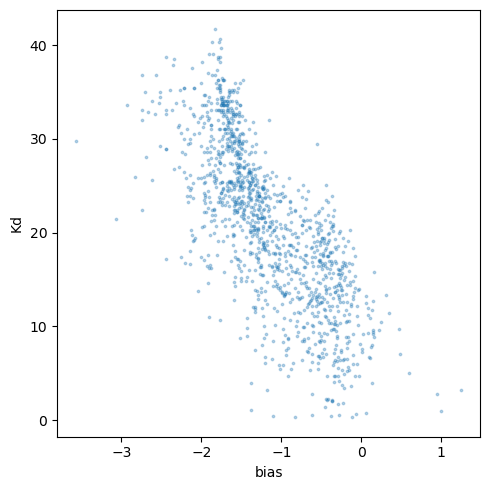

In [102]:
df = pd.read_parquet(f"tutorial_data/{var}_argo_Rss_chlor_a_Kd.parquet")

df_bias = df.copy()

# --- Ensure datetime ---
df_bias['TIME'] = pd.to_datetime(df_bias['TIME'], utc=True, errors='coerce')

# --- Basic cleaning: drop rows missing key fields ---
df_bias = df_bias.dropna(subset=['TIME', 'LONGITUDE', 'CHLA_0_10', 'pace_chlor_a'])

# --- Remove non-positive CHL (can't take log10 of these) ---
df_bias = df_bias[(df_bias['CHLA_0_10'] > 0) & (df_bias['pace_chlor_a'] > 0)]

# --- Compute log10 CHL and bias (PACE - Argo) ---
eps = 1e-6  # tiny offset for numerical safety, but we already filtered <=0
df_bias['log_chl_argo'] = np.log10(df_bias['CHLA_0_10'] + eps)
df_bias['log_chl_sat'] = np.log10(df_bias['pace_chlor_a'] + eps)
df_bias['bias'] = df_bias['log_chl_sat'] - df_bias['log_chl_argo']

# Scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(df_bias['log_chl_argo'], 1/df_bias['pace_Kd_490'], s=3, alpha=0.3)


plt.xlabel("bias")
plt.ylabel("Kd")
plt.tight_layout()
plt.show()

/tmp/ipykernel_25871/3605124069.py:11: RuntimeWarning: divide by zero encountered in log
  y_true = np.log(y_true_raw)
/tmp/ipykernel_25871/3605124069.py:11: RuntimeWarning: invalid value encountered in log
  y_true = np.log(y_true_raw)


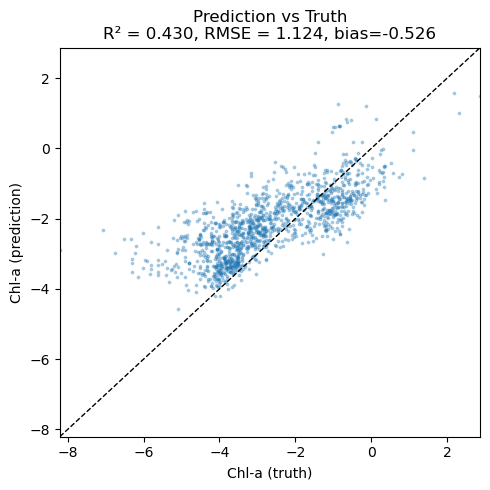

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

df_clean = pd.read_parquet(f"tutorial_data/{var}_argo_Rss_chlor_a_Kd.parquet")

# Take logs (natural log; use np.log10 if you prefer log10)
y_true_raw = df_clean["CHLA_0_10"].values
y_pred_raw = df_clean["pace_chlor_a"].values

y_true = np.log(y_true_raw)
y_pred = np.log(y_pred_raw)

# Mask: positive & finite in both
mask = (
    np.isfinite(y_true) &
    np.isfinite(y_pred) &
    (y_true_raw > 0) &
    (y_pred_raw > 0)
)

y_true = y_true[mask]
y_pred = y_pred[mask]

# Compute some metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = np.mean(y_true-y_pred)

# Scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, s=3, alpha=0.3)

# 1:1 line
lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Chl-a (truth)")
plt.ylabel("Chl-a (prediction)")
plt.title(f"Prediction vs Truth\nR² = {r2:.3f}, RMSE = {rmse:.3f}, bias={bias:.3f}")
plt.tight_layout()
plt.show()

## BBP700

In [25]:
# BBP700
# Load data from GitHub
df_y_name="BBP700"; df_lat_name="LATITUDE"; df_lon_name="LONGITUDE"; df_time_name="TIME"
import pandas as pd
base_url="https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/tutorial_data/"
url = f"{base_url}argo_bgc_global_surface_{df_y_name}.parquet"
df = pd.read_parquet(url)

In [26]:
# BBP700
from pathlib import Path
import pandas as pd

results_dir = Path("data/matchups")
results_dir.mkdir(exist_ok=True)

all_batches = []
batch_size = 10
var = "bbp700"

for batch_idx, i in enumerate(range(0, len(results), batch_size), start=1):
    # If this batch was already done, skip it
    batch_path = results_dir / f"{var}_matchups_batch_{batch_idx:03d}.parquet"
    if batch_path.exists():
        print(f"  -> Skipping batch {batch_idx}, found {batch_path}")
        continue

    batch = results[i:i+batch_size]
    print(f"Batch {batch_idx}: {len(batch)} files")
        
    df_batch = run_batch(batch)  # returns a DataFrame

    # Save this batch immediately
    df_batch.to_parquet(batch_path, index=False)
    print(f"  -> Saved {len(df_batch)} rows to {batch_path}")


  -> Skipping batch 1, found data/matchups/bbp700_matchups_batch_001.parquet
  -> Skipping batch 2, found data/matchups/bbp700_matchups_batch_002.parquet
  -> Skipping batch 3, found data/matchups/bbp700_matchups_batch_003.parquet
  -> Skipping batch 4, found data/matchups/bbp700_matchups_batch_004.parquet
  -> Skipping batch 5, found data/matchups/bbp700_matchups_batch_005.parquet
  -> Skipping batch 6, found data/matchups/bbp700_matchups_batch_006.parquet
  -> Skipping batch 7, found data/matchups/bbp700_matchups_batch_007.parquet
  -> Skipping batch 8, found data/matchups/bbp700_matchups_batch_008.parquet
  -> Skipping batch 9, found data/matchups/bbp700_matchups_batch_009.parquet
  -> Skipping batch 10, found data/matchups/bbp700_matchups_batch_010.parquet
  -> Skipping batch 11, found data/matchups/bbp700_matchups_batch_011.parquet
  -> Skipping batch 12, found data/matchups/bbp700_matchups_batch_012.parquet
  -> Skipping batch 13, found data/matchups/bbp700_matchups_batch_013.par

In [ ]:
# When everything is done, you can merge all batches:
from pathlib import Path
import pandas as pd

var = "bbp700"
results_dir = Path("data/matchups")

batch_files = sorted(results_dir.glob(f"{var}_matchups_batch_*.parquet"))
dfs = [pd.read_parquet(f) for f in batch_files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_parquet(f"tutorial_data/{var}_argo_rss_all.parquet", index=False)
rrs_cols = [c for c in df_all.columns if c.startswith("Rrs_")]
df_all_clean = df_all.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
df_all_clean.to_parquet(f"tutorial_data/{var}_argo_rss.parquet", index=False)

In [5]:
print(f"Total rows: {len(df_all_clean)}")
print(f"Total rows: {len(df_all)}")


Total rows: 5599
Total rows: 29950


---------------------
## Testing stuff

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_true = df_plus.y

# Compute some metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, s=3, alpha=0.3)

# 1:1 line
lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Chl-a (truth)")
plt.ylabel("Chl-a (prediction)")
plt.title(f"Prediction vs Truth\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.tight_layout()
plt.show()

In [67]:
type(fileset[0])

earthaccess.store.EarthAccessFile

In [62]:
# process one file code
import pandas as pd
import earthaccess
import xarray as xr

def test(
    f, df,
    ds_lat_name="lat", ds_lon_name="lon", ds_time_name="time", 
    ds_vec_name="wavelength", ds_var_name="Rrs",
    df_lat_name="lat", df_lon_name="lon", df_time_name="time",
    df_var_name="y"
):
    with xr.open_dataset(f, chunks={}, cache=False) as ds:

        # --- Step 1: subset df to the time window in ds
        t_start = pd.to_datetime(ds.attrs["time_coverage_start"], utc=True)
        t_end   = pd.to_datetime(ds.attrs["time_coverage_end"], utc=True)
        df_times = pd.to_datetime(df[df_time_name], utc=True)
        # df points that are in this record
        df_record = df[(df_times >= t_start) & (df_times < t_end)]
        return t_start, t_end, df_record[df_time_name]
